<a href="https://colab.research.google.com/github/crezny/DATASCI266_final_project/blob/main/Baseline Scoring- New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Scoring Model

In [1]:
%pip install evaluate -q
%pip install rouge_score -q
%pip install sentence_transformers -q
%pip install transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import evaluate
import re
import os
import numpy as np
import pandas as pd
from rouge_score import rouge_scorer, scoring
from sentence_transformers import SentenceTransformer
from typing import List, Dict, Optional, Tuple, Any, Sequence
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import AutoModelForSequenceClassification
import matplotlib.pyplot as plt
import math
import matplotlib.pyplot as plt

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm


from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError
try:
    from google.colab import userdata
    get_secret = userdata.get
except ImportError:
    # Fallback: define a dummy get_secret for local use
    def get_secret(key):
        return None

def get_env(key: str, default: str = None):
    """Tries os.getenv first, then Colab userdata if available."""
    return os.getenv(key) or get_secret(key) or default


DB_HOST = get_env("POSTGRES_DB_HOST")
DB_PORT = int(get_env("POSTGRES_DB_PORT"))
DB_NAME = get_env("POSTGRES_DB_NAME")
DB_USER = get_env("POSTGRES_DB_USER")
DB_PASS = get_env("POSTGRES_DB_PASS")

connection_url = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

### LLM SSM Evaluation

In [3]:
"""Load  semantic similarity model"""
model_name='BAAI/bge-large-en-v1.5'
alternate_sentence_transformer = 'all-MiniLM-L6-v2'
print(f"Loading model: {model_name}...")
sentence_model = SentenceTransformer(model_name)
alternate_sentence_model = SentenceTransformer(alternate_sentence_transformer)
print("Model loaded successfully!\n")


# Load Rouge Scorer
rouge = evaluate.load('rouge')

def embed_bge(texts, batch_size=64):
    # Recommended BGE instruction-style prefix; use the SAME for both sides
    prefixed = [f"Represent this sentence for measuring semantic similarity: {t}" for t in texts]
    return sentence_model.encode(
        prefixed,
        batch_size=batch_size,
        normalize_embeddings=True,        # important: makes dot product == cosine
        convert_to_numpy=True,
        show_progress_bar=True
    )

def embed_minilm(texts, batch_size=64):
    # Recommended BGE instruction-style prefix; use the SAME for both sides
    prefixed = [f"Represent this sentence for measuring semantic similarity: {t}" for t in texts]
    return alternate_sentence_model.encode(
        prefixed,
        batch_size=batch_size,
        normalize_embeddings=True,        # important: makes dot product == cosine
        convert_to_numpy=True,
        show_progress_bar=True
    )


Loading model: BAAI/bge-large-en-v1.5...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!



In [4]:
score_query = """
SELECT model_results.* , d.source_framework, d.section_title, org_text
FROM model_results
JOIN (
SELECT DISTINCT policy_id, section_id, (ARRAY_AGG(section_title ORDER BY row_number))[1] AS section_title , source_framework, string_agg(clause_text, '\n' ORDER BY ROW_NUMBER) AS org_text  FROM policy_lines
GROUP BY policy_id, section_id, source_framework
) AS D
ON D.policy_id = model_results.policy_id and D.section_id = model_results.policy_id || ':S' || section_number
--AND d.source_framework = model_results.source_framework
WHERE model_results.model_type = 'baseline'

"""


engine = create_engine(connection_url, echo=False)
all_scores = pd.read_sql(score_query, con=engine)
all_scores.head()

,policy_id,model_name,output,time_taken,token_count,policy_title,section_number,variant,model_type,execution_date,source_framework,section_title,org_text
0,CL_0001-ASMP-v1.0,Llama-3.2-3B-Instruct,The purpose of this Asset Management Policy is...,6.95,196,Asset Management Policy,1,A,baseline,2025-11-11 23:49:33.577771,NIST CSF,PURPOSE,[COMPANY_NAME] has developed and implemented t...
1,CL_0001-ASMP-v1.0,Gemma-2-9B,This policy establishes the framework for the ...,13.18,153,Asset Management Policy,1,A,baseline,2025-11-11 23:49:33.577771,NIST CSF,PURPOSE,[COMPANY_NAME] has developed and implemented t...
2,CL_0001-ASMP-v1.0,SmolLM3,The purpose of this Asset Management Policy is...,6.25,161,Asset Management Policy,1,A,baseline,2025-11-11 23:49:33.577771,NIST CSF,PURPOSE,[COMPANY_NAME] has developed and implemented t...
3,CL_0001-ASMP-v1.0,Mistral-7B-Instruct-v0.3,This Asset Management Policy is established to...,15.94,256,Asset Management Policy,1,A,baseline,2025-11-11 23:49:33.577771,NIST CSF,PURPOSE,[COMPANY_NAME] has developed and implemented t...
4,CL_0001-ASMP-v1.0,SmolLM3,"Mobile devices, including smartphones, tablets...",9.95,256,Asset Management Policy,3.10.2,A,baseline,2025-11-11 23:49:33.577771,NIST CSF,"Mobile Devices: Smartphones, Tablets, Etc.",Based upon the job duties and responsibilities...


In [5]:
# @title Helper Functions
import re
import numpy as np
from typing import List

WORD_RE = re.compile(r"\b[a-zA-Z][a-zA-Z0-9_-]*\b")

def extract_keywords(text: str) -> List[str]:
    """
    Very simple keyword extractor:
    - lowercase
    - alphanumeric-ish tokens
    - length >= 3
    You can later swap this out for a domain-specific keyword list.
    """
    if not isinstance(text, str):
        return []
    tokens = WORD_RE.findall(text.lower())
    # crude stopword filter; extend as needed
    stop = {"the", "and", "or", "for", "with", "that", "this", "from", "shall", "must", "may"}
    return [t for t in tokens if len(t) >= 3 and t not in stop]

def count_keywords(text: str) -> int:
    # distinct keywords; you could instead use raw count
    return len(set(extract_keywords(text)))

def weighted_harmonic_mean(sem, lex, length, kw,
                           w_sem=0.4, w_lex=0.3, w_len=0.2, w_kw=0.1,
                           eps=1e-8) -> float:
    """
    Weighted harmonic mean of four components.
    Assumes inputs are in [0, 1].
    """
    # clamp to [eps, 1] to avoid exploding weights on zeros
    sem    = max(min(float(sem), 1.0), eps)
    lex    = max(min(float(lex), 1.0), eps)
    length = max(min(float(length), 1.0), eps)
    kw     = max(min(float(kw), 1.0), eps)

    num = w_sem + w_lex + w_len + w_kw
    den = (w_sem / sem) + (w_lex / lex) + (w_len / length) + (w_kw / kw)
    return num / max(den, eps)


In [6]:
# @title Compute Multe STS MDS
def compute_mds_multi_sts(
    df,
    rouge_metric,
    embed_fns: dict,
    text_col: str = "output",
    ref_col: str = "org_clause_text",
    w_sem: float = 0.4,
    w_lex: float = 0.3,
    w_len: float = 0.2,
    w_kw: float = 0.1,
    eps: float = 1e-8,
):
    def strip_think_blocks(x: str) -> str:
        if not isinstance(x, str):
            return ""
        return re.sub(r"<think>.*?</think>", "", x, flags=re.DOTALL).strip()

    df = df.copy()
    df["pred"] = df[text_col].fillna("").astype(str).apply(strip_think_blocks)
    df["gold"] = df[ref_col].fillna("").astype(str).str.strip()

    preds = df["pred"].tolist()
    refs  = df["gold"].tolist()

    # --- Lexical / length / keyword once ---
    rouge_scores = rouge_metric.compute(
        predictions=preds,
        references=refs,
        use_aggregator=False,
    )
    # This is now just a vector of per-example ROUGE-L scores
    S_lexical = np.array(rouge_scores["rougeL"], dtype=float)

    S_length = np.array([
        1.0 if len(g) == 0 and len(p) == 0
        else 0.0 if len(g) == 0 or len(p) == 0
        else min(len(g), len(p)) / max(len(g), len(p))
        for g, p in zip(refs, preds)
    ], dtype=float)

    S_keyword = np.array([
        1.0 if count_keywords(g) == 0
        else max(0.0, min(1.0,
            1.0 - abs(count_keywords(g) - count_keywords(p)) / count_keywords(g)
        ))
        for g, p in zip(refs, preds)
    ], dtype=float)

    df["S_lexical"] = S_lexical
    df["S_length"]  = S_length
    df["S_keyword"] = S_keyword

    # --- STS + MDS for each embedding model ---
    for label, fn in embed_fns.items():
        E_pred = fn(preds)
        E_gold = fn(refs)

        E_pred = E_pred / (np.linalg.norm(E_pred, axis=1, keepdims=True) + eps)
        E_gold = E_gold / (np.linalg.norm(E_gold, axis=1, keepdims=True) + eps)

        S_semantic = np.einsum("ij,ij->i", E_pred, E_gold)

        MDS = np.array([
            weighted_harmonic_mean(
                sem=s_sem,
                lex=s_lex,
                length=s_len,
                kw=s_kw,
                w_sem=w_sem,
                w_lex=w_lex,
                w_len=w_len,
                w_kw=w_kw,
                eps=eps,
            )
            for s_sem, s_lex, s_len, s_kw in zip(S_semantic, S_lexical, S_length, S_keyword)
        ])

        suffix = label.replace("/", "_").replace("-", "_")
        df[f"S_semantic_{suffix}"] = S_semantic
        df[f"MDS_{suffix}"]        = MDS

    return df


In [7]:
embed_fns = {
    "bge": embed_bge,
    "minilm": embed_minilm,
}

mds_df = compute_mds_multi_sts(
    df=all_scores,
    rouge_metric=rouge,
    embed_fns=embed_fns,
    ref_col="org_text",
    text_col="output",
)


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

In [8]:
mds_df.columns

Index(['policy_id', 'model_name', 'output', 'time_taken', 'token_count',
       'policy_title', 'section_number', 'variant', 'model_type',
       'execution_date', 'source_framework', 'section_title', 'org_text',
       'pred', 'gold', 'S_lexical', 'S_length', 'S_keyword', 'S_semantic_bge',
       'MDS_bge', 'S_semantic_minilm', 'MDS_minilm'],
      dtype='object')

In [9]:
cols = ['org_text','output', 'section_number','policy_id', 'policy_title','source_framework', 'time_taken','model_name', 'S_lexical', 'S_length', 'S_keyword']
for embed in embed_fns.keys():
    cols.append(f"S_semantic_{embed}")
    cols.append(f"MDS_{embed}")

sub_scores = mds_df[cols].copy()

sub_scores

,org_text,output,section_number,policy_id,policy_title,source_framework,time_taken,model_name,S_lexical,S_length,S_keyword,S_semantic_bge,MDS_bge,S_semantic_minilm,MDS_minilm
0,[COMPANY_NAME] has developed and implemented t...,The purpose of this Asset Management Policy is...,1,CL_0001-ASMP-v1.0,Asset Management Policy,NIST CSF,6.95,Llama-3.2-3B-Instruct,0.148472,0.406707,0.000000,0.832476,9.999997e-08,0.667407,9.999997e-08
1,[COMPANY_NAME] has developed and implemented t...,This policy establishes the framework for the ...,1,CL_0001-ASMP-v1.0,Asset Management Policy,NIST CSF,13.18,Gemma-2-9B,0.156250,0.516940,0.000000,0.787106,9.999997e-08,0.696554,9.999997e-08
2,[COMPANY_NAME] has developed and implemented t...,The purpose of this Asset Management Policy is...,1,CL_0001-ASMP-v1.0,Asset Management Policy,NIST CSF,6.25,SmolLM3,0.193878,0.491173,0.000000,0.821776,9.999998e-08,0.669075,9.999997e-08
3,[COMPANY_NAME] has developed and implemented t...,This Asset Management Policy is established to...,1,CL_0001-ASMP-v1.0,Asset Management Policy,NIST CSF,15.94,Mistral-7B-Instruct-v0.3,0.129032,0.363846,0.000000,0.731438,9.999997e-08,0.508551,9.999996e-08
4,Based upon the job duties and responsibilities...,"Mobile devices, including smartphones, tablets...",3.10.2,CL_0001-ASMP-v1.0,Asset Management Policy,NIST CSF,9.95,SmolLM3,0.202667,0.609756,0.597015,0.859796,4.096699e-01,0.693734,3.917953e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,Third party and custom application software lo...,"Application log elements shall be captured, re...",3.6,SOC_2-LMP-v1.0,Logging and Monitoring Policy,SOC2,15.83,Mistral-7B-Instruct-v0.3,0.131234,0.918478,0.794393,0.811607,3.202579e-01,0.790383,3.189063e-01
1404,The system shall support the formatting and st...,Formatting and Storage Requirements\n\nAll dat...,3.8,SOC_2-LMP-v1.0,Logging and Monitoring Policy,SOC2,8.99,Llama-3.2-3B-Instruct,0.088235,0.215147,0.000000,0.705699,9.999995e-08,0.498549,9.999995e-08
1405,The system shall support the formatting and st...,Section 3.8 - Formatting and Storage\n\nThe pu...,3.8,SOC_2-LMP-v1.0,Logging and Monitoring Policy,SOC2,15.90,Mistral-7B-Instruct-v0.3,0.119658,0.259499,0.000000,0.745559,9.999996e-08,0.692209,9.999996e-08
1406,The system shall support the formatting and st...,All system and application logs must be format...,3.8,SOC_2-LMP-v1.0,Logging and Monitoring Policy,SOC2,12.98,Gemma-2-9B,0.127168,0.348156,0.000000,0.814807,9.999997e-08,0.738589,9.999997e-08


In [10]:
mds_df.groupby(["source_framework","model_name"])[
    [
        "S_semantic_bge", "S_lexical", "S_length", "MDS_bge",
        "S_semantic_minilm", "S_lexical", "S_length", "MDS_minilm",

    ]
].mean().reset_index()

,source_framework,model_name,S_semantic_bge,S_lexical,S_length,MDS_bge,S_semantic_minilm,S_lexical,S_length,MDS_minilm
0,ISO 27001,Gemma-2-9B,0.787801,0.135336,0.302736,0.044814,0.700872,0.135336,0.302736,0.043332
1,ISO 27001,Llama-3.2-3B-Instruct,0.778894,0.103452,0.229154,0.048512,0.646143,0.103452,0.229154,0.046246
2,ISO 27001,Mistral-7B-Instruct-v0.3,0.763580,0.112751,0.262106,0.043679,0.659995,0.112751,0.262106,0.041874
3,ISO 27001,SmolLM3,0.780880,0.114355,0.242471,0.047169,0.667523,0.114355,0.242471,0.045017
4,NIST CSF,Gemma-2-9B,0.791326,0.138686,0.407535,0.126979,0.689298,0.138686,0.407535,0.124475
5,NIST CSF,Llama-3.2-3B-Instruct,0.792745,0.129197,0.338945,0.114855,0.662535,0.129197,0.338945,0.112139
6,NIST CSF,Mistral-7B-Instruct-v0.3,0.770234,0.132495,0.375895,0.112702,0.667195,0.132495,0.375895,0.110210
7,NIST CSF,SmolLM3,0.787524,0.135337,0.343792,0.117853,0.675511,0.135337,0.343792,0.115154
8,SOC2,Gemma-2-9B,0.790976,0.136429,0.407444,0.121780,0.684759,0.136429,0.407444,0.119075
9,SOC2,Llama-3.2-3B-Instruct,0.777736,0.123912,0.355117,0.121757,0.658377,0.123912,0.355117,0.118462


In [11]:
%pip install neo4j


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.4/325.4 kB 24.5 MB/s eta 0:00:00


In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import re
from neo4j import GraphDatabase
from collections import defaultdict
import pandas as pd
import os
import re
import numpy as np
import math
try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm


from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError
try:
    from google.colab import userdata
    get_secret = userdata.get
except ImportError:
    # Fallback: define a dummy get_secret for local use
    def get_secret(key):
        return None

# from dotenv import load_dotenv
# load_dotenv()


from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError

def get_env(key: str, default: str = None):
    """Tries os.getenv first, then Colab userdata if available."""
    return os.getenv(key) or get_secret(key) or default

NEO4J_URI  = get_env("NEO4J_URI")   # bolt:// or neo4j://
NEO4J_USER = get_env("NEO4J_USER")
NEO4J_PASS = get_env("NEO4J_PASS")
NEO4J_DATABASE = get_env("NEO4J_DATABASE")

DB_HOST = get_env("POSTGRES_DB_HOST")
DB_PORT = int(get_env("POSTGRES_DB_PORT"))
DB_NAME = get_env("POSTGRES_DB_NAME")
DB_USER = get_env("POSTGRES_DB_USER")
DB_PASS = get_env("POSTGRES_DB_PASS")

connection_url = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"



In [13]:
# Skywork Reward Model Evaluator
# ===============================
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import re

# --- Load the Skywork reward model ---
model_name = "Skywork/Skywork-Reward-V2-Llama-3.1-8B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" else torch.float32  # safe default




model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    dtype=dtype,
    device_map= device,
    num_labels=1,  # reward models output a single scalar


)

# --- Token IDs for binary "Yes"/"No" ---
YES_TOKEN_ID = tokenizer.encode("Yes", add_special_tokens=False)[0]
NO_TOKEN_ID  = tokenizer.encode("No",  add_special_tokens=False)[0]


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/993 [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/117M [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [14]:
# Message construction aligned to Skywork reward model format
# ============================================================

POLICY_PRINCIPLE = """
You are evaluating a single policy clause. The clause may have multiple subsections.
You will be provided with the applicable framework, and the controls and subcontrols
that the clause is intended to address. You may also be supplied with the organization's
context (industry, size, risk tolerance, key assets, etc.) when available.
If this context is not provided, you should evaluate the clause based solely on the framework requirements.

Evaluate how well the clause satisfies the following criteria:
1. Be precise, enforceable, and free of ambiguity.
2. Correctly align with the stated framework requirements (e.g., NIST CSF, SOC 2, ISO 27001) when referenced.
3. Reflect the organization's ontology (industry, size, risk tolerance, key assets, etc.) when such context is provided.
4. Avoid hallucinated frameworks, controls, or obligations.
5. Maintain a professional, directive tone appropriate for a formal corporate policy.

Special evaluation rules:
- **If no specific controls or subcontrols are provided**:
  Do *not* penalize the clause for lacking explicit control references.
  Instead, focus on clarity, correctness, and appropriateness for its section type.

- **If the section is an introductory or structural section**
  (for example *Purpose*, *Scope*, *Definitions*, *Roles & Responsibilities*):
  Evaluate it on clarity of intent, relevance to the policy and framework theme, and professional tone.
  Such sections are not expected to contain control implementation details or enforceable requirements.

- **Only assign low scores (<50)** when the clause is clearly off-topic,
  factually incorrect, internally contradictory, or so vague it fails to communicate intent.

Assign a numeric score from 0 to 100, where:
- 0 = completely non-compliant with the principle,
- 50 = partially meets requirements but contains material gaps or ambiguities, and
- 100 = fully compliant and exemplary in clarity, alignment, and tone.

Your goal is to output a single numeric score reflecting how well the clause adheres to these principles.
Do not include any explanations or commentary — only return the numeric score.
""".strip()

def skywork_raw_reward_for_clause(clause_text: str,
                                  subcontrol_text: str) -> float:
    """
    Returns the raw Skywork reward (unbounded scalar) for how well
    `clause_text` performs as an 'answer' under the constraint of `subcontrol_text`.
    """
    messages = [
        {
            "role": "user",
            "content": (
                "You are evaluating the next assistant message, which is a proposed policy clause. "
                "It may include multiple subsections. Use the following principle and framework context to judge it.\n\n"
                f"{POLICY_PRINCIPLE}\n\n"
                "Framework sub-control requirement:\n"
                f"{subcontrol_text}\n\n"
                "Reward higher if it is:\n"
                "- Precise and enforceable (no vague language)\n"
                "- Directly aligned with the sub-control scope and obligations\n"
                "- Complete on key points (who, what, when, how)\n"
                "- Free of contradictions or hallucinated requirements\n"
                "- Professional and directive in tone\n"
                "Penalize if it is vague, off-scope, incorrect, or incomplete."
            ),
        },
        {
            # This is the thing being judged
            "role": "assistant",
            "content": clause_text.strip(),
        },
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    # Model card note: avoid duplicate BOS if present.
    if tokenizer.bos_token and text.startswith(tokenizer.bos_token):
        text = text[len(tokenizer.bos_token):]

    inputs = tokenizer(text, return_tensors="pt", truncation=True).to(model.device)

    with torch.no_grad():
        out = model(**inputs)
        raw = out.logits[0][0].item()

    return float(raw)


In [15]:
def skywork_clause_framework_score(clause_text: str,
                                   subcontrol_text: str) -> float:
    """
    Returns a 0-100 adherence score using Skywork RM as backbone.
    """
    raw = skywork_raw_reward_for_clause(clause_text, subcontrol_text)
    # Logistic squashing: maps (-inf, +inf) -> (0, 1)
    prob = 1.0 / (1.0 + math.exp(-raw))

    # Scale to 0-100
    return float(prob * 100.0)

In [16]:
# Neo4j Framework Context Extraction
# ============================================================

CYPHER_POLICY_FRAMEWORK_MAP = """
MATCH (f:Framework)
WHERE f.name = $framework_name
MATCH (f)-[:HAS_CONTROL_AREA]->(ca:ControlArea)
MATCH (ca)-[:HAS_SUBCONTROL]->(sc:SubControl)
MATCH (sc)-[:REQUIRES_EVIDENCE]->(er:EvidenceRequirement)
MATCH (p:Policy)-[:SATISFIES_REQUIREMENT]->(er)
WHERE p.title = $policy_name
RETURN DISTINCT
  f.name   AS framework_name,
  p.title  AS policy_title,
  ca.name  AS control_name,
  sc.title AS subcontrol_name,
  sc.code    AS subcontrol_id
ORDER BY control_name, subcontrol_name
"""

def get_framework_context_for_policy(policy_name: str,
                                     framework_name: str = "NIST CSF") -> dict:
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))
    try:
        with driver.session(database=NEO4J_DATABASE) as session:
            rows = session.run(
                CYPHER_POLICY_FRAMEWORK_MAP,
                framework_name=framework_name,
                policy_name=policy_name,
            ).data()
    finally:
        driver.close()

    # Group by control area
    by_control = defaultdict(list)
    for r in rows:
        by_control[r["control_name"]].append({
            "id": r.get("subcontrol_id"),
            "name": r["subcontrol_name"],
        })

    return {
        "framework": framework_name,
        "policy": policy_name,
        "controls": [
            {
                "control_area": control,
                "subcontrols": subs,
            }
            for control, subs in by_control.items()
        ]
    }


In [17]:
def render_framework_context(framework_data: dict) -> str:
    """
    Turn your framework-control mapping into a readable context block
    for the evaluation prompt.
    """
    lines = []
    print(framework_data)
    lines.append(f"Framework: {framework_data['framework']}")
    lines.append(f"Policy: {framework_data['policy']}")
    lines.append("")

    for ctrl in framework_data.get("controls", []):
        lines.append(f"Control Area: {ctrl['control_area']}")
        for sc in ctrl.get('subcontrols', []):
            lines.append(f"  - {sc['id']}: {sc['name']}")
        lines.append("")  # blank line between control areas

    return "\n".join(lines).strip()

In [18]:
def get_section_text(df, policy_id: str, section: str, include_children=True) -> str:
    # Filter for this policy
    pdf = df[df['policy_id'] == policy_id].copy()
    if pdf.empty:
        return f"[No content found for policy {policy_id}]"

    # Choose filtering style: exact match or include children (prefix)
    if include_children:
        section_df = pdf[pdf['clause_section_number'].str.startswith(section)]
    else:
        section_df = pdf[pdf['clause_section_number'] == section]

    if section_df.empty:
        return f"[No section {section} found for policy {policy_id}]"

    output_lines = []
    last_section = None

    for _, row in section_df.iterrows():
        sec_num = row['clause_section_number']
        title = row.get('section_title', '')
        text = str(row.get('clause_text', '')).strip()

        # Print header at first appearance of each section/subsection
        if sec_num != last_section:
            header = f"{sec_num} {title}".strip()
            output_lines.append(header)
            last_section = sec_num

        # Add the body text
        if text:
            output_lines.append(text)

    return "\n".join(output_lines)


In [19]:
def get_section_text(df, policy_id: str, section: str, include_children=True) -> str:
    # Filter for this policy
    pdf = df[df['policy_id'] == policy_id].copy()
    if pdf.empty:
        return f"[No content found for policy {policy_id}]"

    # Choose filtering style: exact match or include children (prefix)
    if include_children:
        section_df = pdf[pdf['clause_section_number'].str.startswith(section)]
    else:
        section_df = pdf[pdf['clause_section_number'] == section]

    if section_df.empty:
        return f"[No section {section} found for policy {policy_id}]"

    output_lines = []
    last_section = None

    for _, row in section_df.iterrows():
        sec_num = row['clause_section_number']
        title = row.get('section_title', '')
        text = str(row.get('clause_text', '')).strip()

        # Print header at first appearance of each section/subsection
        if sec_num != last_section:
            header = f"{sec_num} {title}".strip()
            output_lines.append(header)
            last_section = sec_num

        # Add the body text
        if text:
            output_lines.append(text)

    return "\n".join(output_lines)


In [20]:
def add_framework_context_to_df(
    df,
    framework_col: str='source_framework',
    framework_context_col: str='framework_context'
):
    framework_contexts = []
    pbar = tqdm(
        total=len(df),
        desc="Adding framework context",
        unit="clause",
        leave=True
    )

    for index, row in df.iterrows():
        policy_name = row.get('policy_title')
        framework = row.get(framework_col)

        # Update progress bar message dynamically
        pbar.set_postfix({
            "Policy": str(policy_name)[:25],
            "Framework": str(framework)
        })


        framework_data = get_framework_context_for_policy(policy_name, framework)
        context_text = render_framework_context(framework_data)
        framework_contexts.append(context_text)
        pbar.update(1)

    pbar.close()

    df[framework_context_col] = framework_contexts
    return df

In [21]:
def apply_judge(
    df,
    prompt_col: str='clause_full_text',
    framework_col: str='source_framework',
    policy_name_col: str="policy_title",
    section_num_col: str="clause_section_number",
    section_title_col: str="section_title",
    output_col: str="output"
    ):

    scores = []
    pbar = tqdm(
        total=len(df),
        desc="Evaluating policy clauses",
        unit="clause",
        leave=True
    )

    for index, row in df.iterrows():
        policy_name = row.get(policy_name_col)
        section_num = row.get(section_num_col, "")
        section_title = row.get(section_title_col, "")
        framework = row.get(framework_col)
        clause_text = row.get(prompt_col)

        # Update progress bar message dynamically
        pbar.set_postfix({
            "Policy": str(policy_name)[:25],
            "Section": str(section_num),
            "Framework": str(framework)
        })

        section_context = f"Policy: {policy_name}\nSection {section_num}: {section_title}".strip()
        clause_block = f"{section_context}\n\nClause to evaluate:\n{clause_text.strip()}"

        # # Build inputs and run scoring
        framework_data = get_framework_context_for_policy(policy_name, framework)
        score = skywork_clause_framework_score(clause_block, framework_data)
        scores.append(score)
        pbar.update(1)

    pbar.close()

    df[output_col] = scores
    return df


In [22]:
mds_df.iloc[0]

,0
policy_id,CL_0001-ASMP-v1.0
model_name,Llama-3.2-3B-Instruct
output,The purpose of this Asset Management Policy is...
time_taken,6.95
token_count,196
policy_title,Asset Management Policy
section_number,1
variant,A
model_type,baseline
execution_date,2025-11-11 23:49:33.577771


In [23]:
mds_df = apply_judge(mds_df,
    prompt_col='output',
    framework_col='source_framework',
    policy_name_col="policy_title",
    section_num_col="section_number",
    section_title_col="section_title",
    output_col="judged_score"
)

Evaluating policy clauses:   0%|          | 0/1408 [00:00<?, ?clause/s]

In [24]:
len(mds_df)/4
mds_df.groupby(["source_framework","model_name"])[
    [
        "judged_score",

    ]
].mean().reset_index()

,source_framework,model_name,judged_score
0,ISO 27001,Gemma-2-9B,98.788192
1,ISO 27001,Llama-3.2-3B-Instruct,28.637787
2,ISO 27001,Mistral-7B-Instruct-v0.3,39.174586
3,ISO 27001,SmolLM3,53.390604
4,NIST CSF,Gemma-2-9B,96.290023
5,NIST CSF,Llama-3.2-3B-Instruct,27.216142
6,NIST CSF,Mistral-7B-Instruct-v0.3,38.382117
7,NIST CSF,SmolLM3,48.442437
8,SOC2,Gemma-2-9B,98.615475
9,SOC2,Llama-3.2-3B-Instruct,43.455181


In [25]:
# @title Graphy Stack Offsets
def _stack_offsets(
    x_vals: np.ndarray,
    *,
    base_y: float,
    step: float = 0.35,
    precision: int = 3,
) -> np.ndarray:
    """
    Deterministic "beeswarm-like" vertical offsets for repeated x values.
    - Quantizes x by rounding to `precision` decimals.
    - For each quantized bucket, assigns offsets symmetrically around base_y:
        0 -> 0
        1 -> +step
        2 -> -step
        3 -> +2*step
        4 -> -2*step
        ...
    Returns an array of y positions with same shape as x_vals.
    """
    x_vals = np.asarray(x_vals, dtype=float)
    q = np.round(x_vals, precision)
    y = np.empty_like(x_vals, dtype=float)

    # For reproducible ordering, we preserve the original order within each bucket
    # and assign offsets in a symmetric pattern.
    unique_buckets = np.unique(q)
    for b in unique_buckets:
        idx = np.where(q == b)[0]
        n = len(idx)
        if n == 1:
            y[idx[0]] = base_y
            continue

        # symmetric offsets: 0, +1, -1, +2, -2, ...
        ranks = np.arange(n)
        offsets = np.zeros(n, dtype=float)
        # build symmetric sequence
        seq = [0]
        k = 1
        while len(seq) < n:
            seq.append(+k)
            if len(seq) < n:
                seq.append(-k)
            k += 1
        offsets = np.array(seq, dtype=float) * step
        y[idx] = base_y + offsets

    return y


def plot_horizontal_violin_beeswarm_stacked(
    rouge_by_group: Dict[str, List[float]],
    *,
    ax: Optional[plt.Axes] = None,
    xlabel: str = "ROUGE-1",
    line_stat: str = "median",   # 'median' or 'mean'
    cap_height: float = 0.12,
    line_weight: float = 2.0,
    stack_step: float = 0.035,
    precision: int = 3,
    show_global_median: bool = True,
    max_possible: float = 1.0,
    min_possible: float = 0.0,
    title: str = "ROUGE-1 Scores by Model",
    label_suffix: str = "",
    base_color: str = "",   # distribution fill color (default blue)
    dot_color: str = "",
    hide_label: bool = False,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Multi-row horizontal violin + stacked dots + whisker line with end caps.
    Each group (key) gets its own row.

    Parameters are the same as before, plus:
      - ax: optional matplotlib Axes to draw into.
    Returns (fig, ax) without calling plt.show().
    """
    if not isinstance(rouge_by_group, dict) or not rouge_by_group:
        raise ValueError("rouge_by_group must be a non-empty dict of {label: list_of_scores}.")

    labels = list(rouge_by_group.keys())
    data = [np.asarray(rouge_by_group[k], dtype=float) for k in labels]
    positions = np.arange(1, len(labels) + 1, dtype=float)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(9, max(2.0, 0.9 + 0.6 * len(labels))))
    else:
        fig = ax.figure


    ttl = title if not label_suffix else f"{title} — {label_suffix}"
    ax.set_title(ttl)

    # Shaded violins per row
    parts = ax.violinplot(
        data,
        positions=positions,
        vert=False,
        showmeans=False,
        showextrema=False,
        showmedians=False,
    )
    # Light fill for violins
    for pc in parts["bodies"]:
        if base_color != "":
            pc.set_facecolor(base_color)
            pc.set_edgecolor(base_color)
        pc.set_alpha(0.2)
        pc.set_linewidth(0.8)


    # Per-row overlays
    for pos, vals in zip(positions, data):
        if vals.size == 0:
            continue

        # stacked dots (deterministic)
        y = _stack_offsets(vals, base_y=pos, step=stack_step, precision=precision)

        if dot_color != "":
            ax.scatter(vals, y, s=14, alpha=0.85, color=dot_color)
        else:
            ax.scatter(vals, y, s=14, alpha=0.85)

        # whisker line min→max + end caps
        vmin, vmax = float(np.min(vals)), float(np.max(vals))
        ax.hlines(pos, vmin, vmax, linewidth=line_weight)
        # faint extension to max_possible (if vmax < max_possible)
        if vmin > min_possible:
            ax.hlines(
                    pos,
                    min_possible,
                    vmin,
                    linewidth=line_weight,
                    color="gray",
                    alpha=0.3,
                    linestyles="dashed",
                )
        if vmax < max_possible:
            ax.hlines(
                    pos,
                    vmax,
                    max_possible,
                    linewidth=line_weight,
                    color="gray",
                    alpha=0.3,
                    linestyles="dashed"
                )

        cap_y1, cap_y2 = pos - cap_height / 2.0, pos + cap_height / 2.0
        ax.vlines([vmin, vmax], cap_y1, cap_y2, linewidth=line_weight)

        # center stat marker (median or mean)
        stat_val = float(np.median(vals) if line_stat == "median" else np.mean(vals))
        ax.vlines(stat_val, cap_y1, cap_y2, linewidth=line_weight)

    # Optional global median line across all rows
    if show_global_median:
        all_vals = np.concatenate([v for v in data if v.size])
        if all_vals.size:
            stat_val = float(np.median(all_vals) if line_stat == "median" else np.mean(all_vals))
            ax.axvline(stat_val, color="darkgray", linestyle="-", linewidth=line_weight,
                       label=f"{line_stat.title()} = {stat_val:.3f}")

            # Text label near the top, like BLEU avg
            # ax.text(stat_val, len(labels) + 0.6, f"{line_stat.title()} = {stat_val:.3f}",
            #         color="gray", fontsize=9, ha="center", va="bottom")


            ax.legend(frameon=False, fontsize=9, loc="upper right")


    # Styling like a SHAP beeswarm
    ax.set_yticks(positions)

    ax.set_yticklabels(labels)
    for label_text, tick in zip(labels, ax.yaxis.get_major_ticks()):
        if not label_text:  # catches '' or None
            tick.tick1line.set_visible(False)  # left tick
            tick.tick2line.set_visible(False)  # right tick
            tick.label1.set_visible(False)     # hide text as well just in case
    # if xlabel != "":
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.set_ylim(0.5, len(labels) + 0.5)
    # remove all borders
    for spine in ax.spines.values():
        spine.set_visible(False)


    if created_fig:
        fig.tight_layout()
    return fig, ax


In [26]:
# @title Plot Functions
def _fmt(x: float) -> str:
    if x >= 0.1:   return f"{x:.2f}"
    if x >= 0.01:  return f"{x:.3f}"
    return f"{x:.4f}"


def _apply_clean_axes(ax):
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


def plot_single_model_bleu_precisions(
    bleu_results: Dict[str, Any],
    *,
    ax: Optional[plt.Axes] = None,
    ylim: Tuple[float, float] = (0.0, 1.0),
    annotate: bool = True,
    rotation: int = 0,
    title: str = "BLEU n-gram Precisions (single model)",
    ylabel: str = "Precision (0–1)",
    label_suffix: Optional[str] = None,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot 1–4 gram precisions with colored bars and a BLEU average line.
    Expects: bleu_results["precisions"] (list of length 4) and bleu_results["bleu"] (float).
    """
    precisions: Sequence[float] = bleu_results.get("precisions", [float("nan")] * 4)
    p = (list(precisions) + [float("nan")] * 4)[:4]

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(6, 5))
    else:
        fig = ax.figure

    # harmonious palette (you can swap or override if desired)
    colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

    x = np.arange(1, 5)
    bars = ax.bar(x, p, color=colors[: len(p)], edgecolor="black", linewidth=0.5)

    # add BLEU average line if available
    bleu_score = bleu_results.get("bleu")
    if bleu_score is not None and not math.isnan(bleu_score):
        ax.axhline(bleu_score, color="darkgray", linestyle="-", linewidth=1,
                   label=f"BLEU avg = {_fmt(bleu_score)}")
        ax.legend(frameon=False, fontsize=9, loc="upper right")

    # annotate bars
    if annotate:
        for rect, val in zip(bars, p):
            if not math.isnan(val):
                ax.text(rect.get_x() + rect.get_width()/2.0, rect.get_height(),
                        _fmt(val), ha="center", va="bottom", fontsize=9)

    # labels & formatting
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ttl = title if not label_suffix else f"{title} — {label_suffix}"
    ax.set_title(ttl)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}-gram" for i in x], rotation=rotation, ha="center")

    _apply_clean_axes(ax)

    # remove all borders
    for spine in ax.spines.values():
        spine.set_visible(False)


    # footer info
    bp = bleu_results.get("brevity_penalty", None)
    lr = bleu_results.get("length_ratio", None)
    footer_bits = []
    if bp is not None: footer_bits.append(f"BP={_fmt(float(bp))}")
    if lr is not None: footer_bits.append(f"LenRatio={_fmt(float(lr))}")
    if footer_bits:
        ax.text(0.98, -0.12, "  •  ".join(footer_bits), transform=ax.transAxes,
                ha="right", va="top", fontsize=9)

    if created_fig:
        fig.tight_layout()
    return fig, ax


In [27]:
# @title Set Plot Font Styles
def set_plot_font_styles(
    fig,
    axis_size: int = 10,
    title_size: int = 12,
    annotation_size: int = 9,
    title_pad: int = 10,
) -> None:
    """
    Apply consistent font sizes and title spacing to all Axes in a matplotlib Figure.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure containing one or more Axes.
    axis_size : int
        Font size for axis labels and tick labels.
    title_size : int
        Font size for subplot titles.
    annotation_size : int
        Font size for legends and annotation text.
    title_pad : int
        Padding (points) between title and plot area.
    """
    for ax in fig.get_axes():
        # --- Title ---
        ax.title.set_fontsize(title_size)
        # Set consistent title padding (distance above axes)
        title_text = ax.get_title()
        if title_text:
            ax.set_title(title_text, fontsize=title_size, pad=title_pad)

        # --- Axis labels ---
        ax.xaxis.label.set_fontsize(axis_size)
        ax.yaxis.label.set_fontsize(axis_size)

        # --- Tick labels ---
        for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
            tick_label.set_fontsize(axis_size)

        # --- Legend text ---
        leg = ax.get_legend()
        if leg is not None:
            leg.get_title().set_fontsize(annotation_size)
            for text in leg.get_texts():
                text.set_fontsize(annotation_size)

        # --- Annotation text (e.g., BLEU avg or Median labels) ---
        for child in ax.get_children():
            if isinstance(child, plt.Text):
                txt = child.get_text()
                # Skip axis labels & titles
                if txt not in {ax.get_title(), ax.get_xlabel(), ax.get_ylabel()}:
                    child.set_fontsize(annotation_size)

    # Redraw to apply all sizing and layout
    fig.canvas.draw_idle()


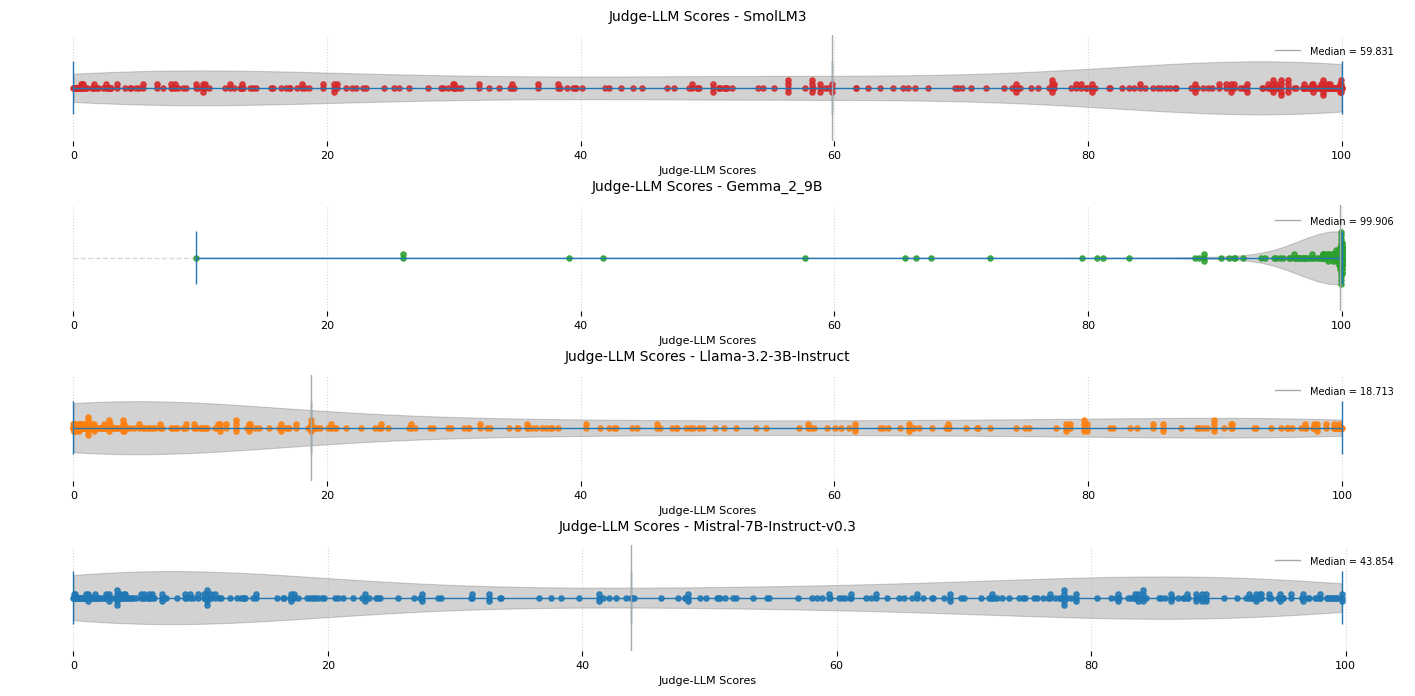

In [44]:
fig, axes = plt.subplots(
    4, 1,
    figsize=(18,8),
    # gridspec_kw={"width_ratios": [7, 3]}   # 70/30 width split
)




axes = axes.flatten()
plot_horizontal_violin_beeswarm_stacked({None: mds_df[mds_df["model_name"] =='SmolLM3']['judged_score'].to_list()}, ax=axes[0]
                                        , xlabel="Judge-LLM Scores"
                                        , line_stat="median"
                                        , title= f"Judge-LLM Scores - SmolLM3"
                                        , max_possible=1.0
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#d62728"
                                        # , hide_label=True
                                        )

plot_horizontal_violin_beeswarm_stacked({"": mds_df[mds_df["model_name"] =='Gemma-2-9B']['judged_score'].to_list()}, ax=axes[1]
                                        , xlabel="Judge-LLM Scores"
                                        , line_stat="median"
                                        , title= f"Judge-LLM Scores - Gemma_2_9B"
                                        , max_possible=1.0
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#2ca02c"
                                        , hide_label=True
                                        )

plot_horizontal_violin_beeswarm_stacked({"": mds_df[mds_df["model_name"] =='Llama-3.2-3B-Instruct']['judged_score'].to_list()}, ax=axes[2]
                                        , xlabel="Judge-LLM Scores"
                                        , line_stat="median"
                                        , title= f"Judge-LLM Scores - Llama-3.2-3B-Instruct"
                                        , max_possible=1.0
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#ff7f0e"
                                        , hide_label=True
                                        )
plot_horizontal_violin_beeswarm_stacked({"": mds_df[mds_df["model_name"] =='Mistral-7B-Instruct-v0.3']['judged_score'].to_list()}, ax=axes[3]
                                        , xlabel="Judge-LLM Scores"
                                        , line_stat="median"
                                        , title= f"Judge-LLM Scores - Mistral-7B-Instruct-v0.3"
                                        , max_possible=1.0
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#1f77b4"
                                        , hide_label=True
                                        )
fig.subplots_adjust(hspace=0.6)
set_plot_font_styles(fig, axis_size=8, title_size=10, annotation_size=7)
plt.show()


In [45]:
fig.savefig("multi_plot.png", bbox_inches="tight", dpi=150)

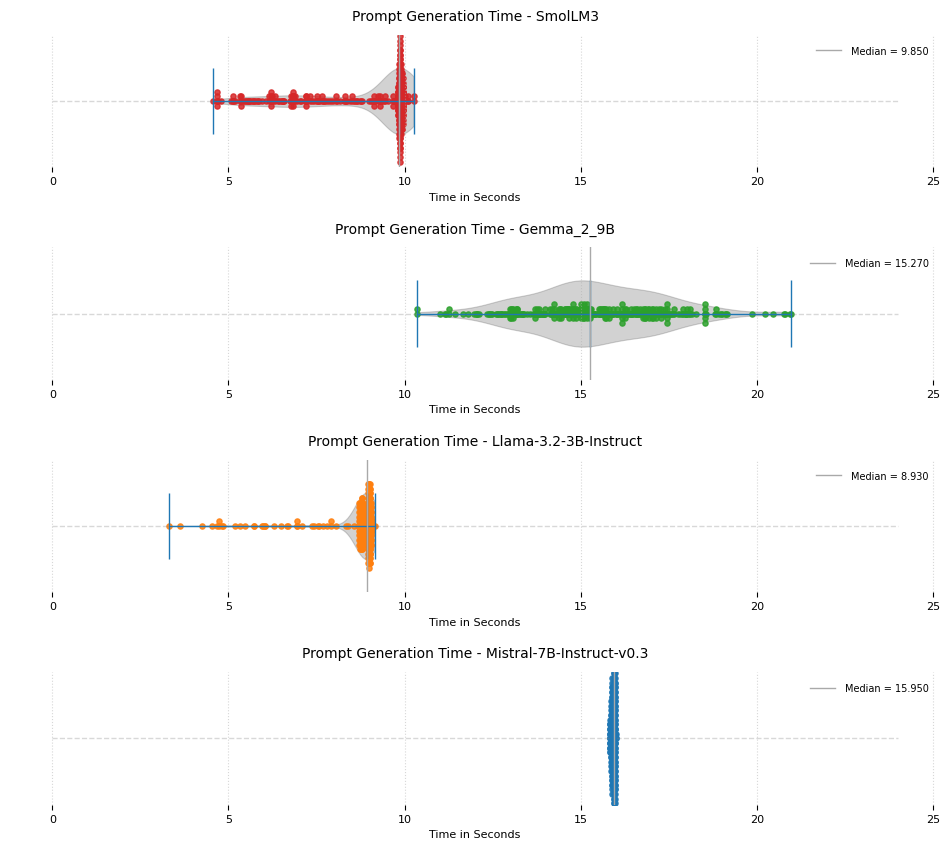

In [30]:
fig, axes = plt.subplots(
    4, 1,
    figsize=(12, 10),
    # gridspec_kw={"width_ratios": [7, 3]}   # 70/30 width split
)
max_time = max(mds_df['time_taken'] )
max_time = math.ceil(max_time * 1.1)



axes = axes.flatten()
plot_horizontal_violin_beeswarm_stacked({None: mds_df[mds_df["model_name"] =='SmolLM3']['time_taken'].to_list()}, ax=axes[0]
                                        , xlabel="Time in Seconds"
                                        , line_stat="median"
                                        , title= f"Prompt Generation Time - SmolLM3"
                                        , max_possible=max_time
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#d62728"
                                        # , hide_label=True
                                        )

plot_horizontal_violin_beeswarm_stacked({"": mds_df[mds_df["model_name"] =='Gemma-2-9B']['time_taken'].to_list()}, ax=axes[1]
                                        , xlabel="Time in Seconds"
                                        , line_stat="median"
                                        , title= f"Prompt Generation Time - Gemma_2_9B"
                                        , max_possible=max_time
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#2ca02c"
                                        , hide_label=True
                                        )

plot_horizontal_violin_beeswarm_stacked({"": mds_df[mds_df["model_name"] =='Llama-3.2-3B-Instruct']['time_taken'].to_list()}, ax=axes[2]
                                        , xlabel="Time in Seconds"
                                        , line_stat="median"
                                        , title= f"Prompt Generation Time - Llama-3.2-3B-Instruct"
                                        , max_possible=max_time
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#ff7f0e"
                                        , hide_label=True
                                        )
plot_horizontal_violin_beeswarm_stacked({"": mds_df[mds_df["model_name"] =='Mistral-7B-Instruct-v0.3']['time_taken'].to_list()}, ax=axes[3]
                                        , xlabel="Time in Seconds"
                                        , line_stat="median"
                                        , title= f"Prompt Generation Time - Mistral-7B-Instruct-v0.3"
                                        , max_possible=max_time
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#1f77b4"
                                        , hide_label=True
                                        )
fig.subplots_adjust(hspace=0.6)
set_plot_font_styles(fig, axis_size=8, title_size=10, annotation_size=7)
plt.show()


In [31]:
fig.savefig("multi_plot2.png", bbox_inches="tight", dpi=150)

In [32]:
mds_df['source_framework'].unique()

array(['NIST CSF', 'SOC2', 'ISO 27001'], dtype=object)

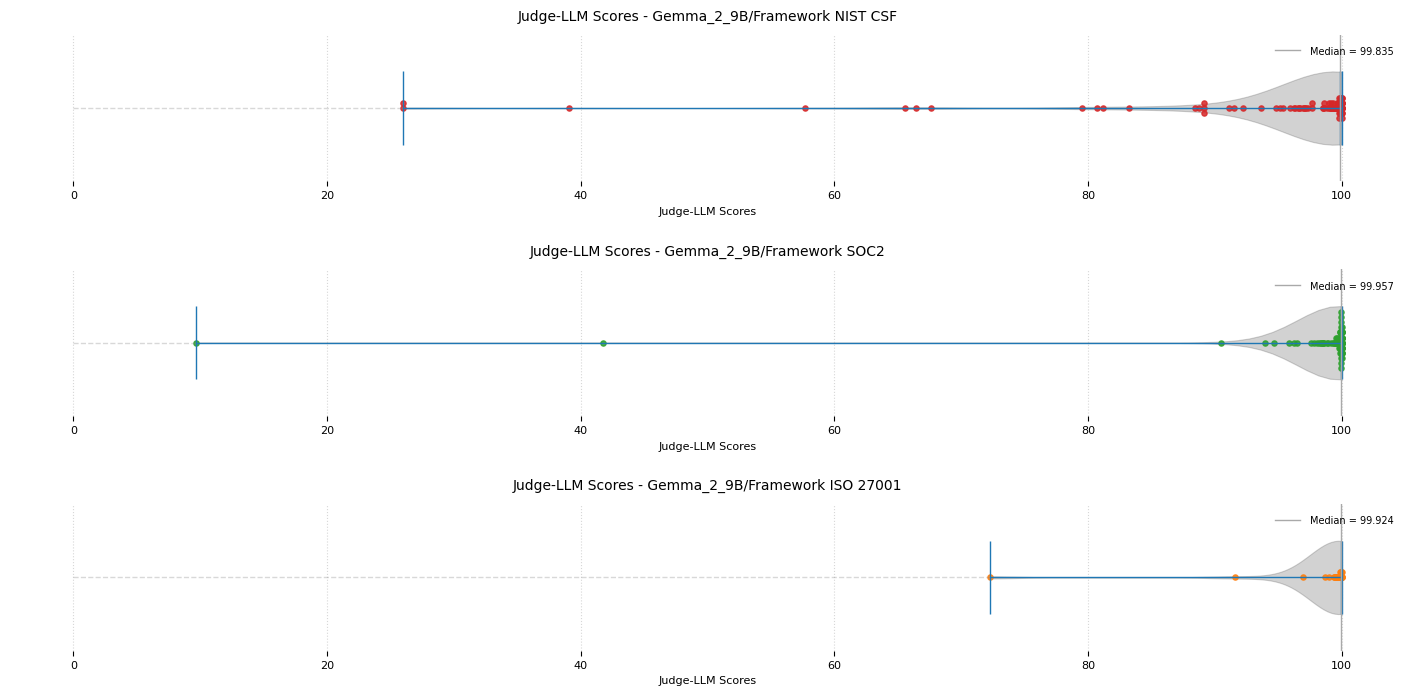

In [46]:
fig, axes = plt.subplots(
    3, 1,
    figsize=(18,8),
    # gridspec_kw={"width_ratios": [7, 3]}   # 70/30 width split
)




axes = axes.flatten()
plot_horizontal_violin_beeswarm_stacked({None: mds_df[(mds_df["model_name"] =='Gemma-2-9B') & (mds_df["source_framework"] =='NIST CSF')]['judged_score'].to_list()}, ax=axes[0]
                                        , xlabel="Judge-LLM Scores"
                                        , line_stat="median"
                                        , title= f"Judge-LLM Scores - Gemma_2_9B/Framework NIST CSF"
                                        , max_possible=1.0
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#d62728"
                                        # , hide_label=True
                                        )

plot_horizontal_violin_beeswarm_stacked({"": mds_df[(mds_df["model_name"] =='Gemma-2-9B') & (mds_df["source_framework"] =='SOC2')]['judged_score'].to_list()}, ax=axes[1]
                                        , xlabel="Judge-LLM Scores"
                                        , line_stat="median"
                                        , title= f"Judge-LLM Scores - Gemma_2_9B/Framework SOC2"
                                        , max_possible=1.0
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#2ca02c"
                                        , hide_label=True
                                        )

plot_horizontal_violin_beeswarm_stacked({"": mds_df[(mds_df["model_name"] =='Gemma-2-9B') & (mds_df["source_framework"] =='ISO 27001')]['judged_score'].to_list()}, ax=axes[2]
                                        , xlabel="Judge-LLM Scores"
                                        , line_stat="median"
                                        , title= f"Judge-LLM Scores - Gemma_2_9B/Framework ISO 27001"
                                        , max_possible=1.0
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#ff7f0e"
                                        , hide_label=True
                                        )

fig.subplots_adjust(hspace=0.6)
set_plot_font_styles(fig, axis_size=8, title_size=10, annotation_size=7)
plt.show()


In [47]:
fig.savefig("multi_plot3.png", bbox_inches="tight", dpi=150)

In [35]:
mds_df['model_type'].unique()

array(['baseline'], dtype=object)

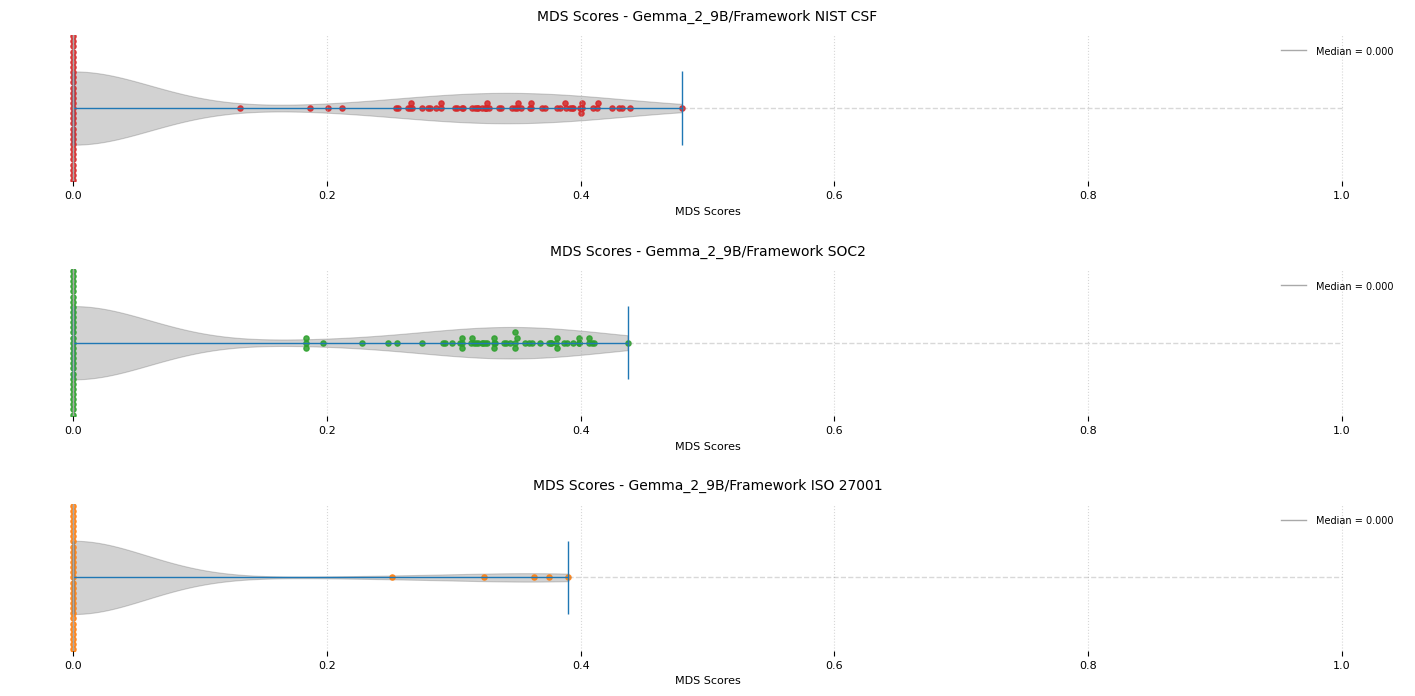

In [36]:
fig, axes = plt.subplots(
    3, 1,
    figsize=(18,8),
    # gridspec_kw={"width_ratios": [7, 3]}   # 70/30 width split
)




axes = axes.flatten()
plot_horizontal_violin_beeswarm_stacked({None: mds_df[(mds_df["model_name"] =='Gemma-2-9B') & (mds_df["source_framework"] =='NIST CSF')]['MDS_bge'].to_list()}, ax=axes[0]
                                        , xlabel="MDS Scores"
                                        , line_stat="median"
                                        , title= f"MDS Scores - Gemma_2_9B/Framework NIST CSF"
                                        , max_possible=1
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#d62728"
                                        # , hide_label=True
                                        )

plot_horizontal_violin_beeswarm_stacked({"": mds_df[(mds_df["model_name"] =='Gemma-2-9B') & (mds_df["source_framework"] =='SOC2')]['MDS_bge'].to_list()}, ax=axes[1]
                                        , xlabel="MDS Scores"
                                        , line_stat="median"
                                        , title= f"MDS Scores - Gemma_2_9B/Framework SOC2"
                                        , max_possible=1
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#2ca02c"
                                        , hide_label=True
                                        )

plot_horizontal_violin_beeswarm_stacked({"": mds_df[(mds_df["model_name"] =='Gemma-2-9B') & (mds_df["source_framework"] =='ISO 27001')]['MDS_bge'].to_list()}, ax=axes[2]
                                        , xlabel="MDS Scores"
                                        , line_stat="median"
                                        , title= f"MDS Scores - Gemma_2_9B/Framework ISO 27001"
                                        , max_possible=1
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#ff7f0e"
                                        , hide_label=True
                                        )

fig.subplots_adjust(hspace=0.6)
set_plot_font_styles(fig, axis_size=8, title_size=10, annotation_size=7)
plt.show()

In [37]:
fig.savefig("multi_plot4.png", bbox_inches="tight", dpi=150)

In [38]:
mds_df.columns

Index(['policy_id', 'model_name', 'output', 'time_taken', 'token_count',
       'policy_title', 'section_number', 'variant', 'model_type',
       'execution_date', 'source_framework', 'section_title', 'org_text',
       'pred', 'gold', 'S_lexical', 'S_length', 'S_keyword', 'S_semantic_bge',
       'MDS_bge', 'S_semantic_minilm', 'MDS_minilm', 'judged_score'],
      dtype='object')

In [39]:
save_out = mds_df[['policy_id', 'model_name', 'policy_title', 'section_number',
                   'variant', 'model_type', 'execution_date', 'source_framework',
                   'section_title', 'S_lexical', 'S_length', 'S_keyword',
                   'S_semantic_bge', 'MDS_bge', 'judged_score']].copy()

save_out.rename(columns={'S_lexical': 'S_lex', 'S_length': 'S_len',
                         'S_semantic_bge': 'S_sem', 'MDS_bge' : 'MDS'})

engine = create_engine(connection_url, echo=False)


In [43]:
save_out = save_out[["policy_id",
          "model_name",
          "policy_title",
          "section_number",
          "variant",
          "model_type",
          "execution_date",
          "source_framework",
          "section_title",
          "S_lexical",
          "S_length",
          "S_keyword",
          "S_semantic_bge",
          "MDS_bge",
          "judged_score"]]

save_out.to_sql(con = engine, name = "scores", if_exists="append", index=False)

408

In [ ]:
len(mds_df)/4

352.0

In [ ]:
mds_df[(mds_df['policy_id'] == "CL_0003-CCE-v1.0") & (mds_df['model_name'] == "SmolLM3") & (mds_df['section_number'] == "2")]

,policy_id,model_name,output,time_taken,token_count,policy_title,section_number,variant,model_type,execution_date,...,pred,gold,S_lexical,S_length,S_keyword,S_semantic_bge,MDS_bge,S_semantic_minilm,MDS_minilm,judged_score
516,CL_0003-CCE-v1.0,SmolLM3,The Scope of this Code of Conduct and Ethics P...,6.83,176,Code of Conduct and Ethics Policy,2,A,baseline,2025-11-11 23:49:33.577771,...,The Scope of this Code of Conduct and Ethics P...,"This policy applies to all employees, contract...",0.164948,0.824561,0.933333,0.780036,0.372961,0.614478,0.354685,99.058741


In [ ]:
mds_df

,policy_id,model_name,output,time_taken,token_count,policy_title,section_number,variant,model_type,execution_date,...,pred,gold,S_lexical,S_length,S_keyword,S_semantic_bge,MDS_bge,S_semantic_minilm,MDS_minilm,judged_score
0,CL_0001-ASMP-v1.0,Llama-3.2-3B-Instruct,The purpose of this Asset Management Policy is...,6.95,196,Asset Management Policy,1,A,baseline,2025-11-11 23:49:33.577771,...,The purpose of this Asset Management Policy is...,[COMPANY_NAME] has developed and implemented t...,0.148472,0.406707,0.000000,0.832476,9.999997e-08,0.667407,9.999997e-08,97.805175
1,CL_0001-ASMP-v1.0,Gemma-2-9B,This policy establishes the framework for the ...,13.18,153,Asset Management Policy,1,A,baseline,2025-11-11 23:49:33.577771,...,This policy establishes the framework for the ...,[COMPANY_NAME] has developed and implemented t...,0.156250,0.516940,0.000000,0.787106,9.999997e-08,0.696554,9.999997e-08,98.967185
2,CL_0001-ASMP-v1.0,SmolLM3,The purpose of this Asset Management Policy is...,6.25,161,Asset Management Policy,1,A,baseline,2025-11-11 23:49:33.577771,...,The purpose of this Asset Management Policy is...,[COMPANY_NAME] has developed and implemented t...,0.193878,0.491173,0.000000,0.821776,9.999998e-08,0.669075,9.999997e-08,97.023991
3,CL_0001-ASMP-v1.0,Mistral-7B-Instruct-v0.3,This Asset Management Policy is established to...,15.94,256,Asset Management Policy,1,A,baseline,2025-11-11 23:49:33.577771,...,This Asset Management Policy is established to...,[COMPANY_NAME] has developed and implemented t...,0.129032,0.363846,0.000000,0.731438,9.999997e-08,0.508551,9.999996e-08,61.091782
4,CL_0001-ASMP-v1.0,SmolLM3,"Mobile devices, including smartphones, tablets...",9.95,256,Asset Management Policy,3.10.2,A,baseline,2025-11-11 23:49:33.577771,...,"Mobile devices, including smartphones, tablets...",Based upon the job duties and responsibilities...,0.202667,0.609756,0.597015,0.859796,4.096699e-01,0.693734,3.917953e-01,7.807817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,SOC_2-LMP-v1.0,Mistral-7B-Instruct-v0.3,"Application log elements shall be captured, re...",15.83,256,Logging and Monitoring Policy,3.6,A,baseline,2025-11-11 23:49:33.577771,...,"Application log elements shall be captured, re...",Third party and custom application software lo...,0.131234,0.918478,0.794393,0.811607,3.202579e-01,0.790383,3.189063e-01,99.682732
1404,SOC_2-LMP-v1.0,Llama-3.2-3B-Instruct,Formatting and Storage Requirements\n\nAll dat...,8.99,257,Logging and Monitoring Policy,3.8,A,baseline,2025-11-11 23:49:33.577771,...,Formatting and Storage Requirements\n\nAll dat...,The system shall support the formatting and st...,0.088235,0.215147,0.000000,0.705699,9.999995e-08,0.498549,9.999995e-08,78.266248
1405,SOC_2-LMP-v1.0,Mistral-7B-Instruct-v0.3,Section 3.8 - Formatting and Storage\n\nThe pu...,15.90,256,Logging and Monitoring Policy,3.8,A,baseline,2025-11-11 23:49:33.577771,...,Section 3.8 - Formatting and Storage\n\nThe pu...,The system shall support the formatting and st...,0.119658,0.259499,0.000000,0.745559,9.999996e-08,0.692209,9.999996e-08,86.246753
1406,SOC_2-LMP-v1.0,Gemma-2-9B,All system and application logs must be format...,12.98,150,Logging and Monitoring Policy,3.8,A,baseline,2025-11-11 23:49:33.577771,...,All system and application logs must be format...,The system shall support the formatting and st...,0.127168,0.348156,0.000000,0.814807,9.999997e-08,0.738589,9.999997e-08,99.958268
